In [1]:
# Clean up and redownload
!rm -rf /kafka
!rm -f kafka_2.13-3.6.2.tgz

!wget https://archive.apache.org/dist/kafka/3.6.2/kafka_2.13-3.6.2.tgz

# Verify download completed properly
!ls -lh kafka_2.13-3.6.2.tgz

--2026-03-12 06:11:49--  https://archive.apache.org/dist/kafka/3.6.2/kafka_2.13-3.6.2.tgz
Resolving archive.apache.org (archive.apache.org)... 65.108.204.189, 2a01:4f9:1a:a084::2
Connecting to archive.apache.org (archive.apache.org)|65.108.204.189|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 113845082 (109M) [application/x-gzip]
Saving to: ‘kafka_2.13-3.6.2.tgz’

kafka_2.13-3.6.2.tg 100%[===================>] 108.57M  2.70MB/s    in 28s     

2026-03-12 06:12:18 (3.81 MB/s) - ‘kafka_2.13-3.6.2.tgz’ saved [113845082/113845082]

-rw-r--r-- 1 root root 109M Apr  4  2024 kafka_2.13-3.6.2.tgz


In [2]:
!tar -xzf kafka_2.13-3.6.2.tgz
!mv kafka_2.13-3.6.2 /kafka
!ls /kafka/bin/
print(" Kafka installed successfully")

connect-distributed.sh	      kafka-metadata-quorum.sh
connect-mirror-maker.sh       kafka-metadata-shell.sh
connect-plugin-path.sh	      kafka-mirror-maker.sh
connect-standalone.sh	      kafka-producer-perf-test.sh
kafka-acls.sh		      kafka-reassign-partitions.sh
kafka-broker-api-versions.sh  kafka-replica-verification.sh
kafka-cluster.sh	      kafka-run-class.sh
kafka-configs.sh	      kafka-server-start.sh
kafka-console-consumer.sh     kafka-server-stop.sh
kafka-console-producer.sh     kafka-storage.sh
kafka-consumer-groups.sh      kafka-streams-application-reset.sh
kafka-consumer-perf-test.sh   kafka-topics.sh
kafka-delegation-tokens.sh    kafka-transactions.sh
kafka-delete-records.sh       kafka-verifiable-consumer.sh
kafka-dump-log.sh	      kafka-verifiable-producer.sh
kafka-e2e-latency.sh	      trogdor.sh
kafka-features.sh	      windows
kafka-get-offsets.sh	      zookeeper-security-migration.sh
kafka-jmx.sh		      zookeeper-server-start.sh
kafka-leader-election.sh      zookeeper-

In [3]:
!apt-get install -y openjdk-17-jdk-headless -q
!pip install pyspark==3.5.3 kafka-python -q
!wget -q https://archive.apache.org/dist/kafka/3.6.2/kafka_2.13-3.6.2.tgz
!tar -xzf kafka_2.13-3.6.2.tgz
!mv kafka_2.13-3.6.2 /kafka

!mkdir -p /kafka_jars
!wget -q https://repo1.maven.org/maven2/org/apache/spark/spark-sql-kafka-0-10_2.12/3.5.3/spark-sql-kafka-0-10_2.12-3.5.3.jar -P /kafka_jars/
!wget -q https://repo1.maven.org/maven2/org/apache/spark/spark-token-provider-kafka-0-10_2.12/3.5.3/spark-token-provider-kafka-0-10_2.12-3.5.3.jar -P /kafka_jars/
!wget -q https://repo1.maven.org/maven2/org/apache/kafka/kafka-clients/3.4.1/kafka-clients-3.4.1.jar -P /kafka_jars/
!wget -q https://repo1.maven.org/maven2/org/apache/commons/commons-pool2/2.11.1/commons-pool2-2.11.1.jar -P /kafka_jars/

print(" All installations done — now restart the runtime!")
print("Go to Runtime → Restart Runtime, then run Cell 2 onwards")

Reading package lists...
Building dependency tree...
Reading state information...
openjdk-17-jdk-headless is already the newest version (17.0.17+10-1~22.04).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.3/317.3 MB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 326.3/326.3 kB 25.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.0.2 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.3 which is incompatible.
✅ All installations done — now restart the runtime!
Go to Runtime → Restart Runtime, then run Cell 2 onwards


In [4]:
import os, subprocess, time

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

zk = subprocess.Popen(
    ["/kafka/bin/zookeeper-server-start.sh", "/kafka/config/zookeeper.properties"],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
)
time.sleep(6)

kb = subprocess.Popen(
    ["/kafka/bin/kafka-server-start.sh", "/kafka/config/server.properties"],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
)
time.sleep(10)
!ss -tlnp | grep 9092

LISTEN 0      50                 *:9092             *:*    users:(("java",pid=1964,fd=154))       


In [5]:
from pyspark.sql import SparkSession

jar_path = ",".join([
    "/kafka_jars/spark-sql-kafka-0-10_2.12-3.5.3.jar",
    "/kafka_jars/spark-token-provider-kafka-0-10_2.12-3.5.3.jar",
    "/kafka_jars/kafka-clients-3.4.1.jar",
    "/kafka_jars/commons-pool2-2.11.1.jar"
])

spark = SparkSession.builder \
    .appName("TelcoChurn_Production_Grade") \
    .config("spark.jars", jar_path) \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

print(" Spark version:", spark.version)

✅ Spark version: 3.5.3


In [6]:
from google.colab import files
uploaded = files.upload()

!/kafka/bin/kafka-topics.sh --create --topic telco-churn \
    --bootstrap-server localhost:9092 \
    --partitions 1 --replication-factor 1

import pandas as pd
from kafka import KafkaProducer
import json

producer = KafkaProducer(
    bootstrap_servers='localhost:9092',
    value_serializer=lambda v: json.dumps(v).encode('utf-8')
)

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
for _, row in df.iterrows():
    producer.send("telco-churn", value=row.to_dict())

producer.flush()
producer.close()
print(f" Produced {len(df)} records to Kafka")

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
Created topic telco-churn.
✅ Produced 7043 records to Kafka


In [7]:
from pyspark.sql import functions as F
from pyspark.sql.types import *

churn_schema = StructType([
    StructField("customerID", StringType(), True),
    StructField("gender", StringType(), True),
    StructField("SeniorCitizen", IntegerType(), True),
    StructField("Partner", StringType(), True),
    StructField("Dependents", StringType(), True),
    StructField("tenure", IntegerType(), True),
    StructField("PhoneService", StringType(), True),
    StructField("MultipleLines", StringType(), True),
    StructField("InternetService", StringType(), True),
    StructField("OnlineSecurity", StringType(), True),
    StructField("OnlineBackup", StringType(), True),
    StructField("DeviceProtection", StringType(), True),
    StructField("TechSupport", StringType(), True),
    StructField("StreamingTV", StringType(), True),
    StructField("StreamingMovies", StringType(), True),
    StructField("Contract", StringType(), True),
    StructField("PaperlessBilling", StringType(), True),
    StructField("PaymentMethod", StringType(), True),
    StructField("MonthlyCharges", DoubleType(), True),
    StructField("TotalCharges", StringType(), True),
    StructField("Churn", StringType(), True)
])

def read_bronze():
    print("--- [BRONZE] Ingesting from Kafka ---")
    raw = spark.read \
        .format("kafka") \
        .option("kafka.bootstrap.servers", "localhost:9092") \
        .option("subscribe", "telco-churn") \
        .option("startingOffsets", "earliest") \
        .load()

    parsed = raw.select(
        F.from_json(F.col("value").cast("string"), churn_schema).alias("data")
    ).select("data.*")

    print(f"   Records ingested: {parsed.count()}")
    return parsed

def process_silver(df):
    print("--- [SILVER] Cleaning & Enforcing Quality ---")

    df_clean = df.withColumn("TotalCharges",
                             F.when(F.col("TotalCharges") == " ", None)
                              .otherwise(F.col("TotalCharges")).cast(DoubleType()))

    initial_count = df_clean.count()
    df_clean = df_clean.na.drop(subset=["TotalCharges", "customerID"])
    dropped_count = initial_count - df_clean.count()
    print(f"   DQ Check: Dropped {dropped_count} rows due to data quality issues.")

    df_clean = df_clean.withColumn("label",
                                   F.when(F.col("Churn") == "Yes", 1).otherwise(0))

    return df_clean

raw_df = read_bronze()
silver_df = process_silver(raw_df)
silver_df.show(5, truncate=False)

--- [BRONZE] Ingesting from Kafka ---
   Records ingested: 7043
--- [SILVER] Cleaning & Enforcing Quality ---
   DQ Check: Dropped 11 rows due to data quality issues.
+----------+------+-------------+-------+----------+------+------------+----------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+-------------------------+--------------+------------+-----+-----+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|MultipleLines   |InternetService|OnlineSecurity|OnlineBackup|DeviceProtection|TechSupport|StreamingTV|StreamingMovies|Contract      |PaperlessBilling|PaymentMethod            |MonthlyCharges|TotalCharges|Churn|label|
+----------+------+-------------+-------+----------+------+------------+----------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+-------------------------+-------

  EXPLORATORY DATA ANALYSIS — TELCO CUSTOMER CHURN DATASET

Dataset Overview & Target Variable Distribution


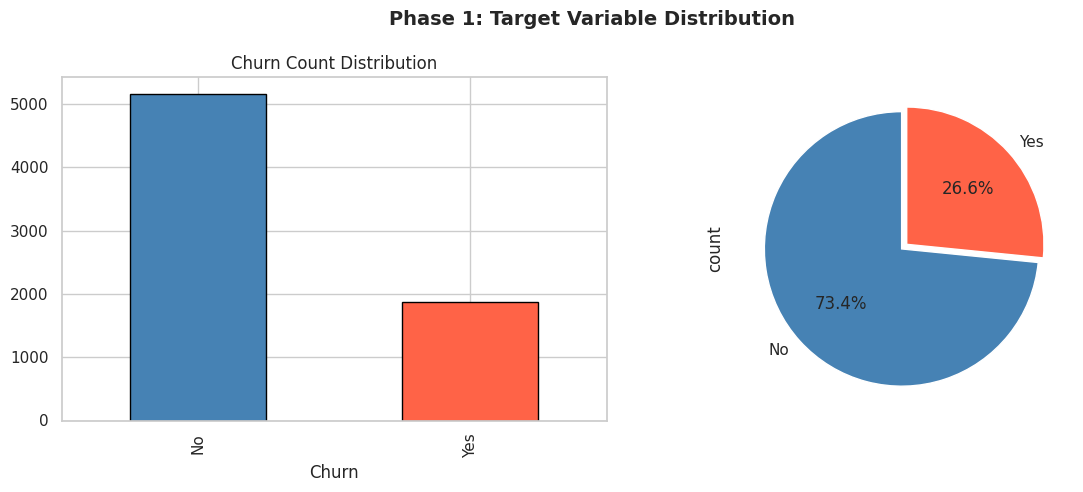


 Churn Rate Across All Categorical Features


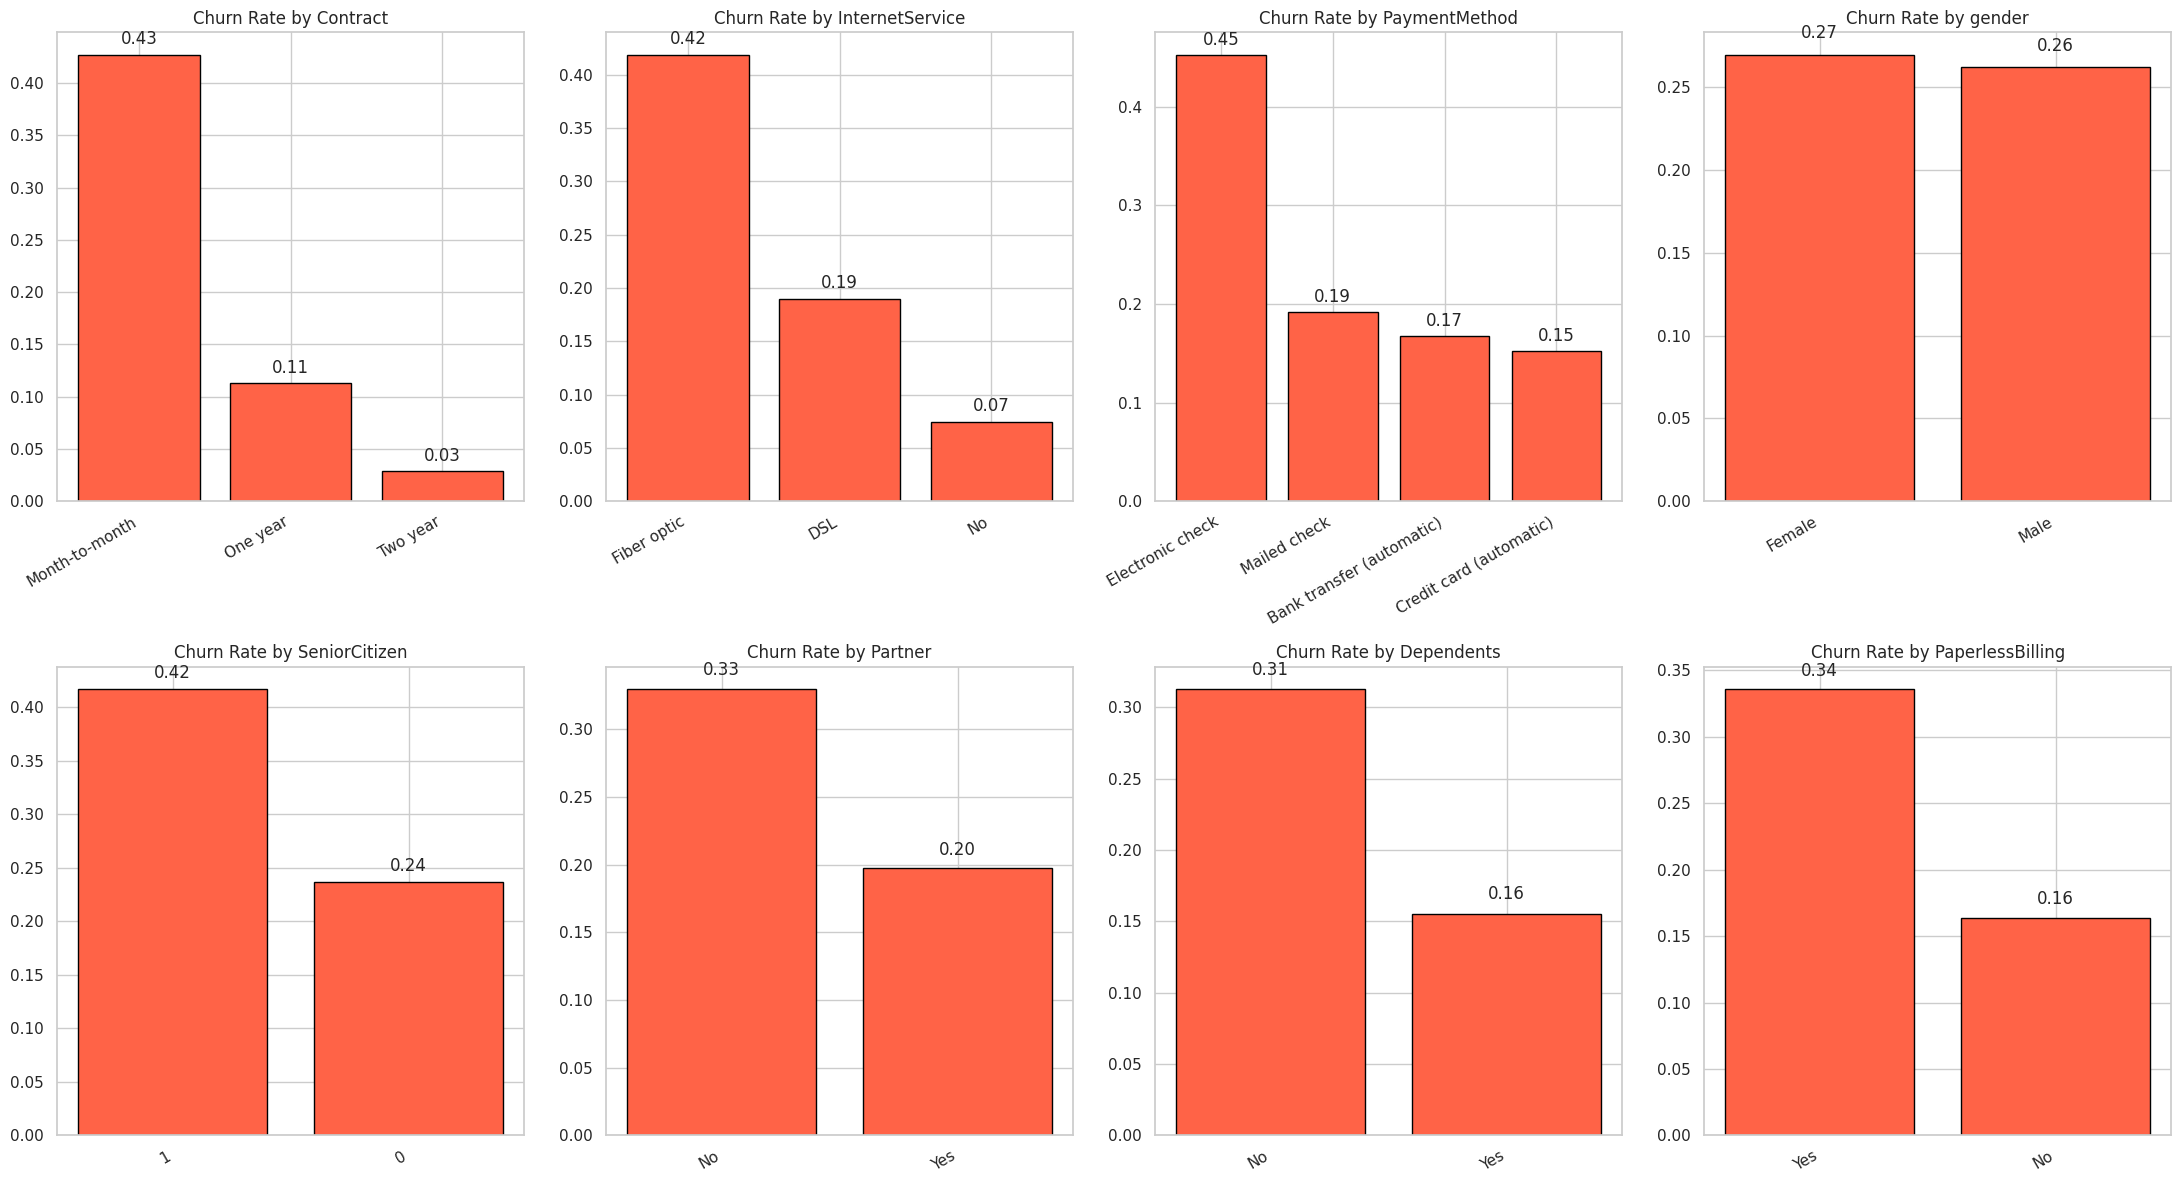


Churn Rate vs Segment Size (The Business Impact)


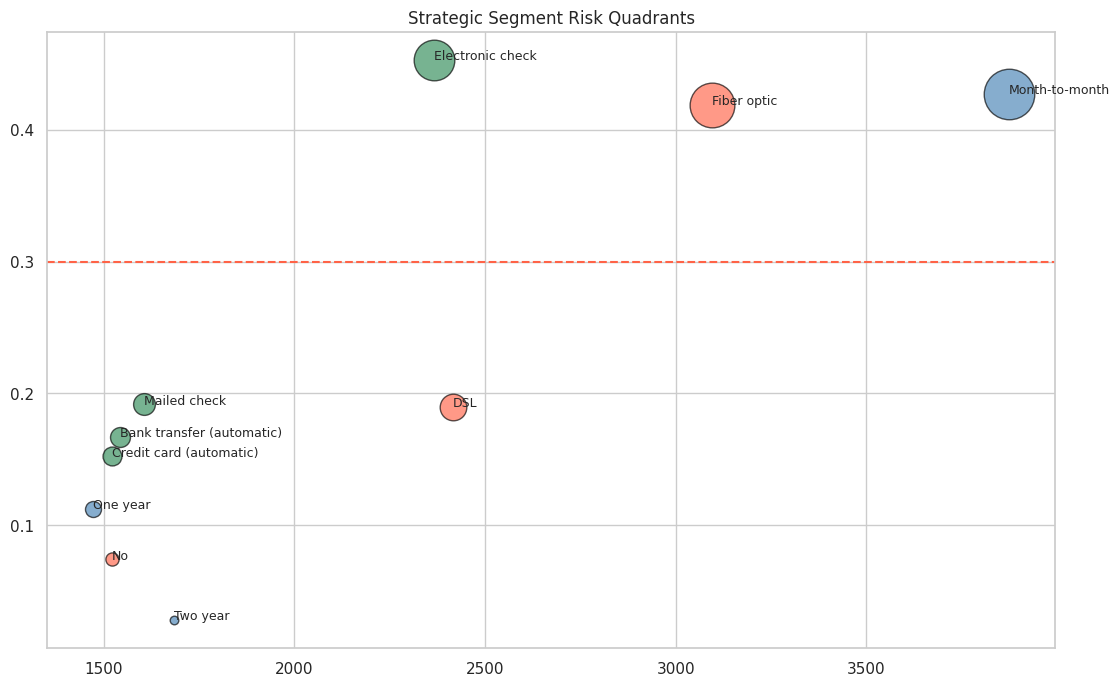


Section 4: Tenure Cohort Analysis — Non-Linear Risk


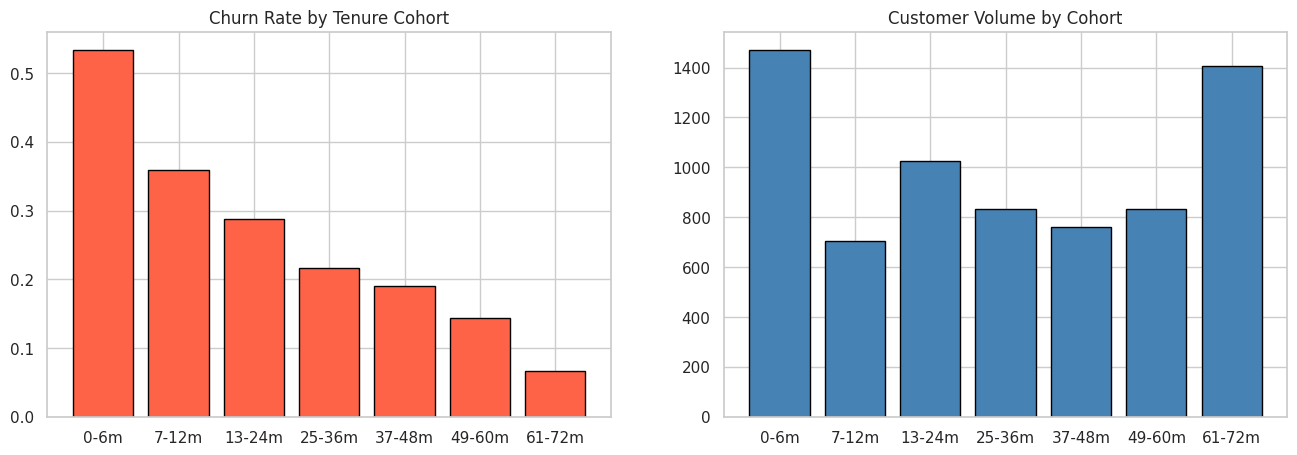


Section 10: CDF — Cumulative Probability of Churn


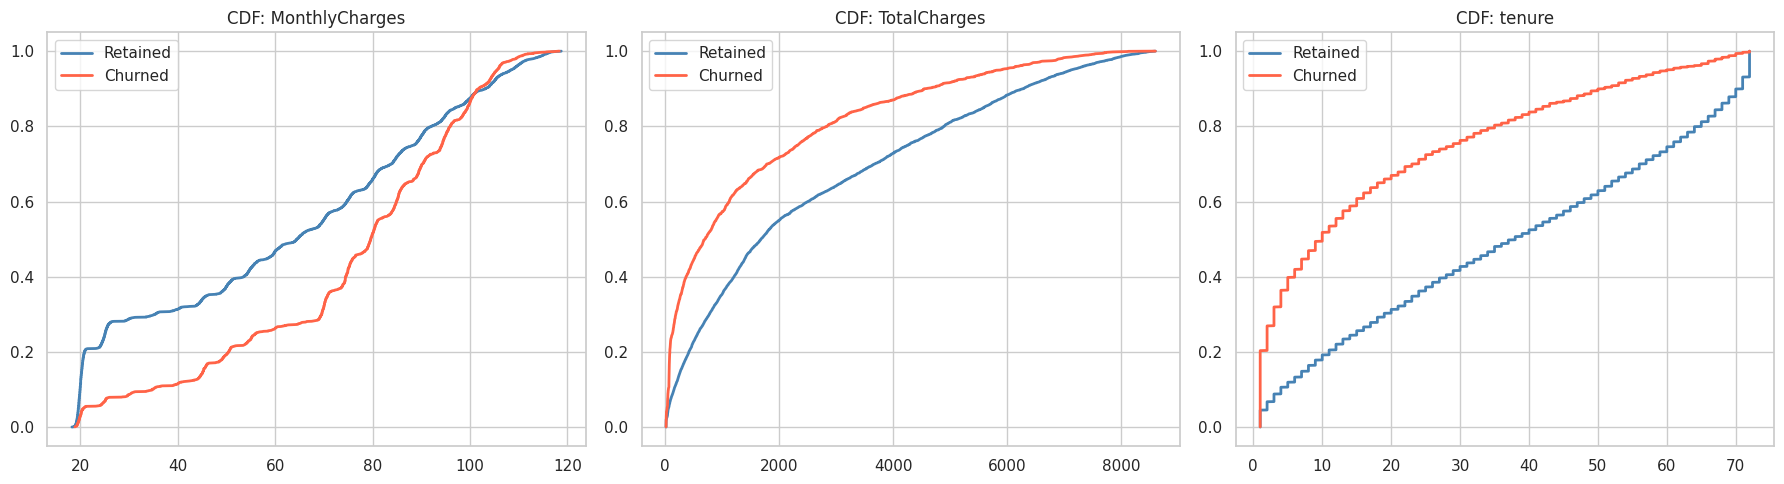


Section 3: Numerical Feature Distributions


/tmp/ipykernel_548/4057390468.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=silver_pd, ax=axes[1][idx], palette=['steelblue', 'tomato'])
/tmp/ipykernel_548/4057390468.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=silver_pd, ax=axes[1][idx], palette=['steelblue', 'tomato'])
/tmp/ipykernel_548/4057390468.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=silver_pd, ax=axes[1][idx], palette=['steelblue', 'tomato'])


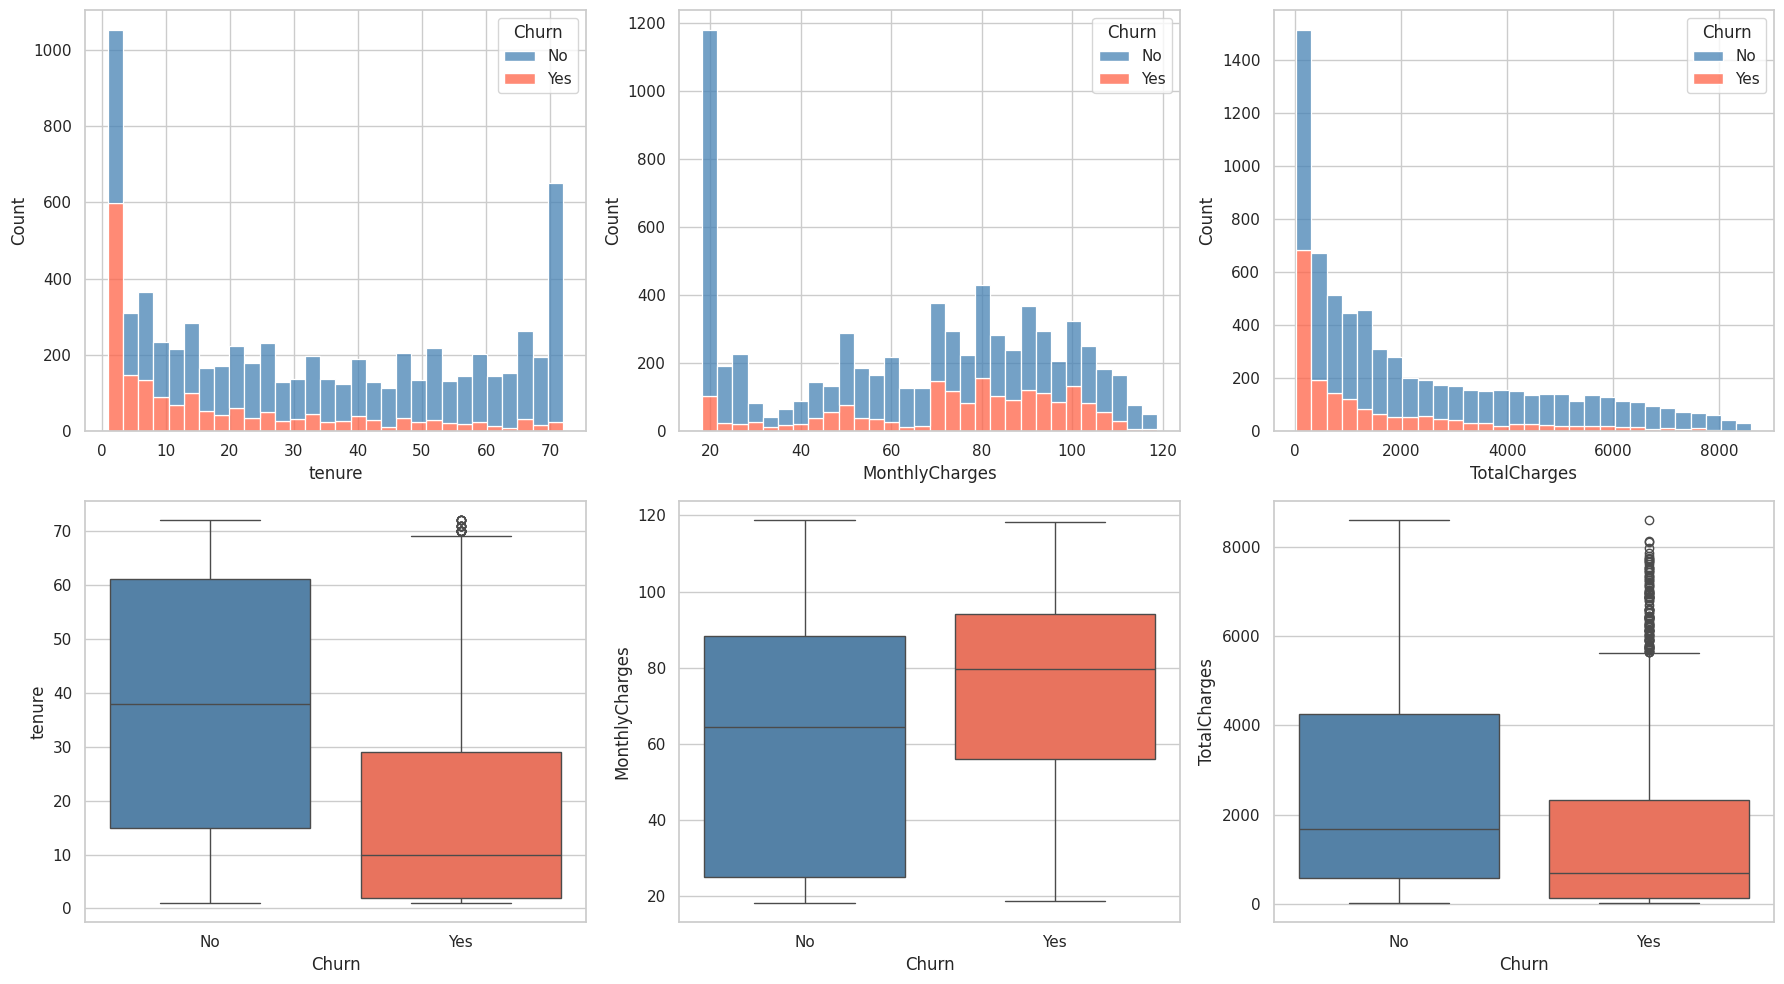


Section 7: The 'Risk Score' Logic (Tenure x Charges)


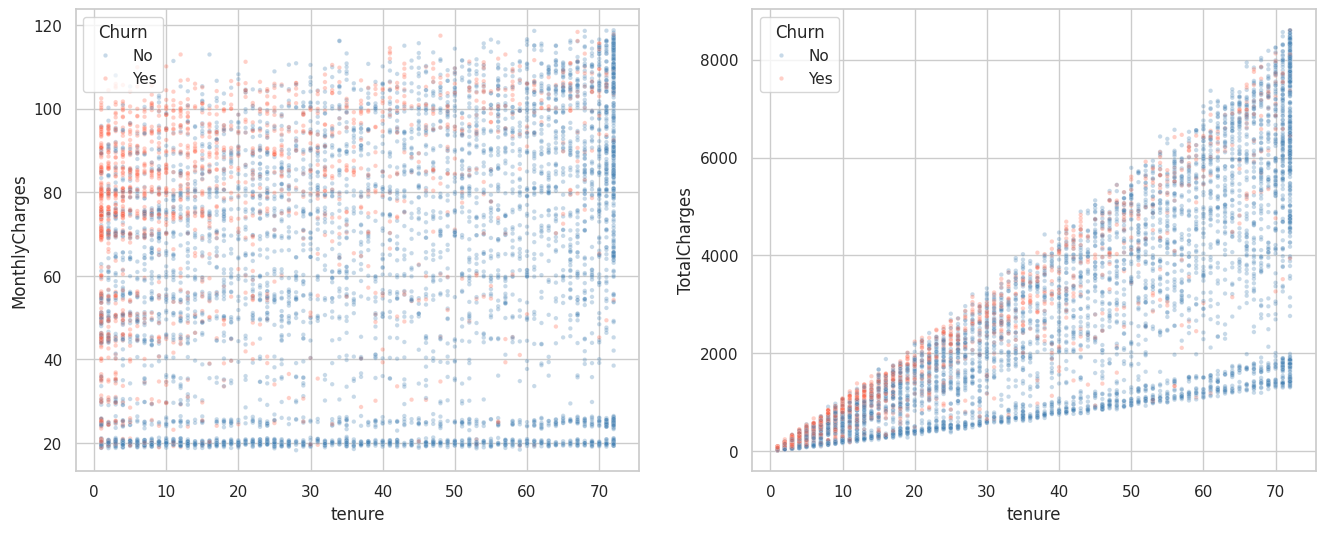


Section 6: Service Adoption Rate (Utility vs Entertainment)


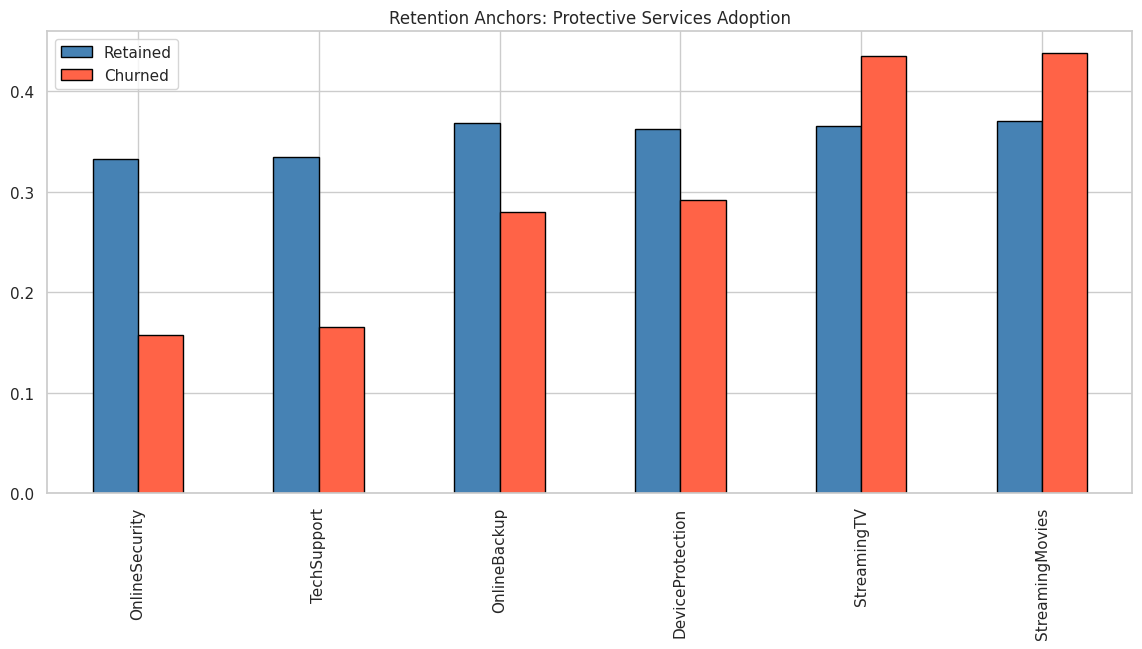


Section 11: Stacked Service Adoption by Contract Type


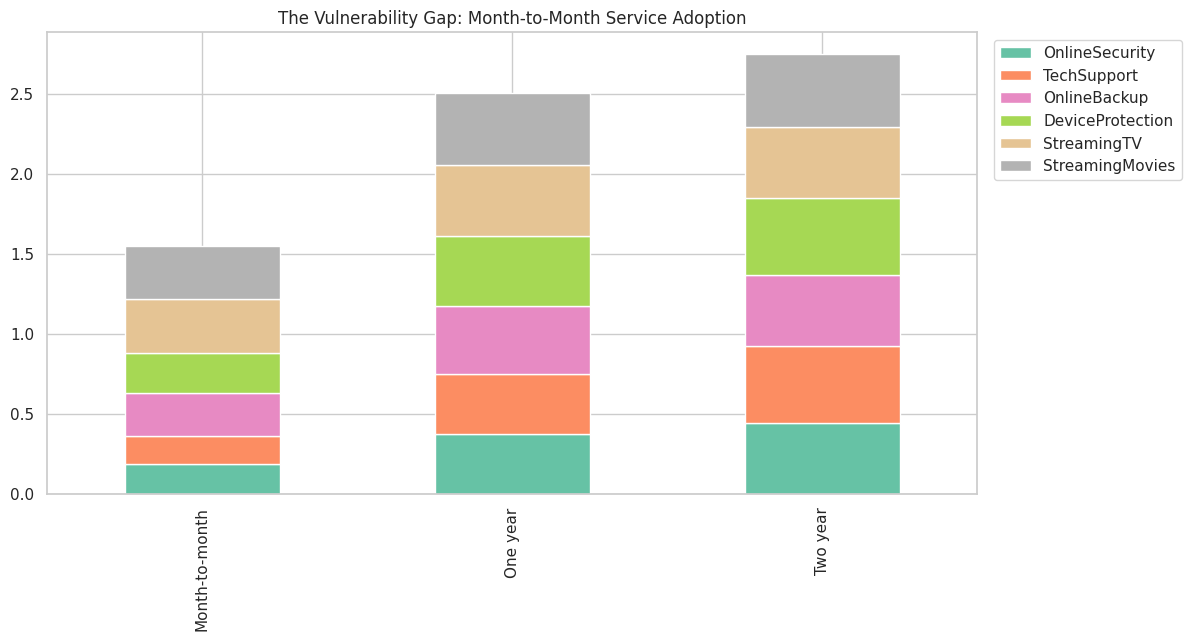


Section 8: Correlation Analysis


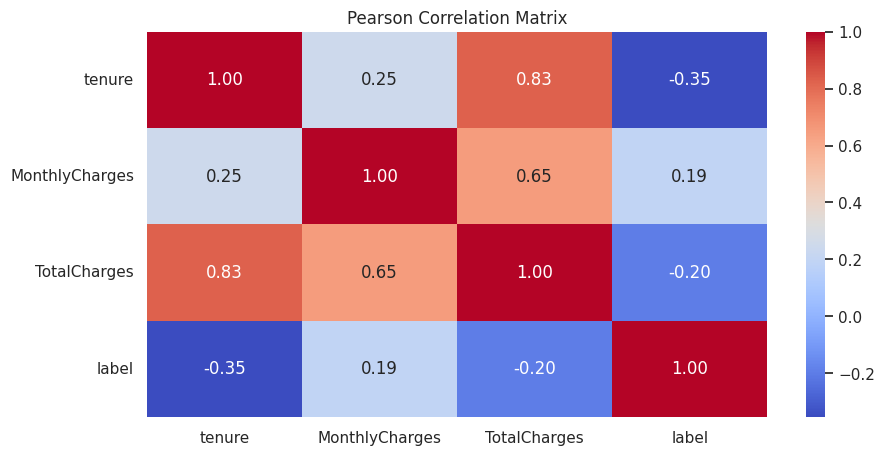


Section 9: Lorenz Curve (Churn Concentration)


/tmp/ipykernel_548/4057390468.py:145: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  plt.plot(cum_cust, cum_churn, marker='o', color='tomato', label=f'Gini: {1 - 2 * np.trapz(cum_churn, cum_cust):.3f}')


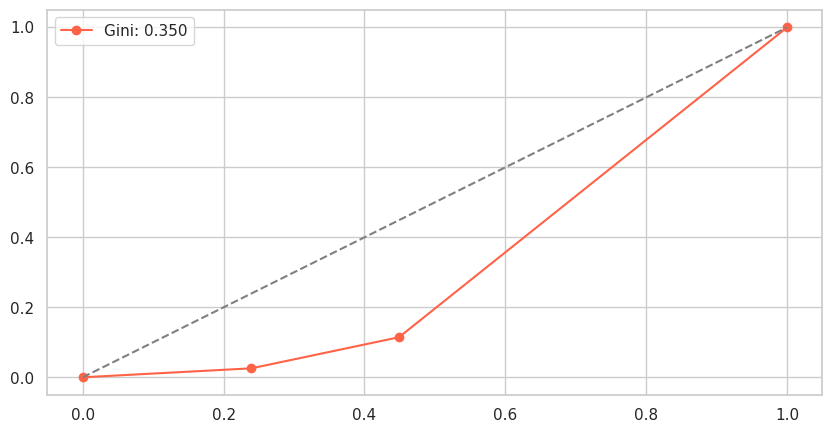


Section 12: Statistical Dispersion Analysis

--- tenure Statistics ---
Churn          No          Yes
count  5163.00000  1869.000000
mean     37.65001    17.979133
std      24.07694    19.531123
min       1.00000     1.000000
25%      15.00000     2.000000
50%      38.00000    10.000000
75%      61.00000    29.000000
max      72.00000    72.000000

--- MonthlyCharges Statistics ---
Churn           No          Yes
count  5163.000000  1869.000000
mean     61.307408    74.441332
std      31.094557    24.666053
min      18.250000    18.850000
25%      25.100000    56.150000
50%      64.450000    79.650000
75%      88.475000    94.200000
max     118.750000   118.350000

--- TotalCharges Statistics ---
Churn           No          Yes
count  5163.000000  1869.000000
mean   2555.317451  1531.751993
std    2329.387290  1890.657024
min      18.800000    18.850000
25%     577.825000   134.500000
50%    1683.600000   703.550000
75%    4264.125000  2331.300000
max    8602.375000  8602.375000

  FI

In [26]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats as scipy_stats

# Convert to Pandas for plotting
silver_pd = silver_df.toPandas()
sns.set_theme(style="whitegrid")

# ==============================================================================
# PHASE 1: THE MACRO VIEW (WHO & WHAT)
# ==============================================================================
print("=" * 65)
print("  EXPLORATORY DATA ANALYSIS — TELCO CUSTOMER CHURN DATASET")
print("=" * 65)

# --- Section 1: Target Distribution ---
print("\nDataset Overview & Target Variable Distribution")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
silver_pd['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Churn Count Distribution')
silver_pd['Churn'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90, explode=(0, 0.05))
plt.suptitle('Phase 1: Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Section 5: Categorical Sweep ---
print("\n Churn Rate Across All Categorical Features")
cat_features = ['Contract', 'InternetService', 'PaymentMethod', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PaperlessBilling']
fig, axes = plt.subplots(2, 4, figsize=(22, 12))
axes = axes.flatten()
for idx, col in enumerate(cat_features):
    churn_rate = silver_pd.groupby(col)['label'].mean().sort_values(ascending=False)
    bars = axes[idx].bar(range(len(churn_rate)), churn_rate.values, color='tomato', edgecolor='black')
    axes[idx].set_xticks(range(len(churn_rate)))
    axes[idx].set_xticklabels(churn_rate.index, rotation=30, ha='right')
    axes[idx].set_title(f'Churn Rate by {col}')
    for bar, rate in zip(bars, churn_rate.values):
        axes[idx].annotate(f'{rate:.2f}', (bar.get_x() + bar.get_width()/2, rate + 0.01), ha='center')
plt.tight_layout()
plt.show()

# --- Section 13: Strategic Bubble Chart ---
print("\nChurn Rate vs Segment Size (The Business Impact)")
segment_cols = ['Contract', 'InternetService', 'PaymentMethod']
segment_stats = []
for col in segment_cols:
    for val in silver_pd[col].unique():
        subset = silver_pd[silver_pd[col] == val]
        segment_stats.append({'segment': f"{col}: {val}", 'customer_count': len(subset), 'churn_rate': subset['label'].mean(), 'churner_count': subset['label'].sum(), 'category': col})
seg_df = pd.DataFrame(segment_stats)
fig, ax = plt.subplots(figsize=(13, 8))
category_colors = {'Contract': 'steelblue', 'InternetService': 'tomato', 'PaymentMethod': 'seagreen'}
for _, row in seg_df.iterrows():
    ax.scatter(row['customer_count'], row['churn_rate'], s=row['churner_count']*0.8, color=category_colors[row['category']], alpha=0.65, edgecolors='black')
    ax.annotate(row['segment'].split(': ')[1], (row['customer_count'], row['churn_rate']), fontsize=9)
ax.axhline(y=0.30, color='tomato', linestyle='--', label='High Risk Threshold')
ax.set_title('Strategic Segment Risk Quadrants')
plt.show()

# ==============================================================================
# PHASE 2: THE TIME DYNAMICS (WHEN THEY LEAVE)
# ==============================================================================
# --- Section 4: Cohort Analysis ---
print("\nSection 4: Tenure Cohort Analysis — Non-Linear Risk")
silver_pd['tenure_bin'] = pd.cut(silver_pd['tenure'], bins=[0, 6, 12, 24, 36, 48, 60, 72], labels=['0-6m', '7-12m', '13-24m', '25-36m', '37-48m', '49-60m', '61-72m'])
cohort_churn = silver_pd.groupby('tenure_bin', observed=True)['label'].agg(['mean', 'count']).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(cohort_churn['tenure_bin'], cohort_churn['mean'], color='tomato', edgecolor='black')
axes[0].set_title('Churn Rate by Tenure Cohort')
axes[1].bar(cohort_churn['tenure_bin'], cohort_churn['count'], color='steelblue', edgecolor='black')
axes[1].set_title('Customer Volume by Cohort')
plt.show()

# --- Section 10: CDF (Precision Distribution) ---
print("\nSection 10: CDF — Cumulative Probability of Churn")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['MonthlyCharges', 'TotalCharges', 'tenure']):
    for churn_val, color, label in [('No', 'steelblue', 'Retained'), ('Yes', 'tomato', 'Churned')]:
        subset = silver_pd[silver_pd['Churn'] == churn_val][col].dropna().sort_values()
        cdf = np.arange(1, len(subset) + 1) / len(subset)
        ax.plot(subset, cdf, color=color, linewidth=2, label=label)
    ax.set_title(f'CDF: {col}')
    ax.legend()
plt.tight_layout()
plt.show()

# ==============================================================================
# PHASE 3: FINANCIALS & INTERACTIONS (COST VS LOYALTY)
# ==============================================================================
# --- Section 3: Distribution Analysis ---
print("\nSection 3: Numerical Feature Distributions")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.histplot(data=silver_pd, x=col, hue='Churn', bins=30, ax=axes[0][idx], palette=['steelblue', 'tomato'], multiple="stack")
    sns.boxplot(x='Churn', y=col, data=silver_pd, ax=axes[1][idx], palette=['steelblue', 'tomato'])
plt.tight_layout()
plt.show()

# --- Section 7: Multivariate Clusters ---
print("\nSection 7: The 'Risk Score' Logic (Tenure x Charges)")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (x_col, y_col) in zip(axes, [('tenure', 'MonthlyCharges'), ('tenure', 'TotalCharges')]):
    sns.scatterplot(data=silver_pd, x=x_col, y=y_col, hue='Churn', alpha=0.3, s=10, ax=ax, palette=['steelblue', 'tomato'])
plt.show()


# ==============================================================================
# PHASE 4: PRODUCT STICKINESS (WHY THEY STAY)
# ==============================================================================
# --- Section 6: Service Adoption ---
print("\nSection 6: Service Adoption Rate (Utility vs Entertainment)")
service_cols = ['OnlineSecurity', 'TechSupport', 'OnlineBackup', 'DeviceProtection', 'StreamingTV', 'StreamingMovies']
churn_services = silver_pd[silver_pd['Churn'] == 'Yes'][service_cols].apply(lambda x: (x == 'Yes').mean())
retain_services = silver_pd[silver_pd['Churn'] == 'No'][service_cols].apply(lambda x: (x == 'Yes').mean())
pd.DataFrame({'Retained': retain_services, 'Churned': churn_services}).plot(kind='bar', figsize=(14, 6), color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Retention Anchors: Protective Services Adoption')
plt.show()

# --- Section 11: Service Composition by Contract ---
print("\nSection 11: Stacked Service Adoption by Contract Type")
contract_service = {c: {s: (silver_pd[silver_pd['Contract'] == c][s] == 'Yes').mean() for s in service_cols} for c in silver_pd['Contract'].unique()}
contract_service_df = pd.DataFrame(contract_service).T
contract_service_df.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2', edgecolor='white')
plt.title('The Vulnerability Gap: Month-to-Month Service Adoption')
plt.legend(bbox_to_anchor=(1.01, 1))
plt.show()

# ==============================================================================
# PHASE 5: STATISTICAL RIGOR (MODEL VALIDATION)
# ==============================================================================
# --- Section 8: Correlation ---
print("\nSection 8: Correlation Analysis")
sns.heatmap(silver_pd[['tenure', 'MonthlyCharges', 'TotalCharges', 'label']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Pearson Correlation Matrix')
plt.show()

# --- Section 9: Lorenz & Gini ---
print("\nSection 9: Lorenz Curve (Churn Concentration)")
contract_churn = silver_pd.groupby('Contract').agg(cust=('customerID', 'count'), churn=('label', 'sum')).reset_index().sort_values('churn')
cum_cust = np.concatenate([[0], np.cumsum(contract_churn['cust']) / contract_churn['cust'].sum()])
cum_churn = np.concatenate([[0], np.cumsum(contract_churn['churn']) / contract_churn['churn'].sum()])
plt.plot(cum_cust, cum_churn, marker='o', color='tomato', label=f'Gini: {1 - 2 * np.trapz(cum_churn, cum_cust):.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.legend()

plt.show()

# --- Section 12: Dispersion Table ---
print("\nSection 12: Statistical Dispersion Analysis")
for feature in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    print(f"\n--- {feature} Statistics ---")
    print(silver_pd.groupby('Churn')[feature].describe().T)

print("\n" + "=" * 65)
print("  FINAL MODELLING RATIONALE LOADED")
print("=" * 65)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [10]:
# --- [EDA] Outlier Detection + Winsorization ---
def handle_outliers(df, col_name):
    quantiles = df.stat.approxQuantile(col_name, [0.25, 0.75], 0.01)
    q1, q3 = quantiles[0], quantiles[1]
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Print outliers before capping
    outliers = df.filter(
        (F.col(col_name) < lower_bound) | (F.col(col_name) > upper_bound)
    )
    outlier_count = outliers.count()

    print(f"--- [EDA] Outlier Report for {col_name} ---")
    print(f"   Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")
    print(f"   Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(f"   Outliers Found: {outlier_count}")

    if outlier_count > 0:
        print(f"   Sample Outliers:")
        outliers.select("customerID", col_name, "label").show(5, truncate=False)

    # Winsorization — cap instead of remove
    df_capped = df.withColumn(col_name,
        F.when(F.col(col_name) < lower_bound, lower_bound)
         .when(F.col(col_name) > upper_bound, upper_bound)
         .otherwise(F.col(col_name))
    )
    print(f"    Winsorization applied: values capped to [{lower_bound:.2f}, {upper_bound:.2f}]")
    return df_capped

# Apply to all numerical columns
silver_df = handle_outliers(silver_df, "TotalCharges")
silver_df = handle_outliers(silver_df, "MonthlyCharges")
silver_df = handle_outliers(silver_df, "tenure")

# --- [EDA] Correlation Analysis ---
print("\n--- [EDA] Correlation Analysis ---")
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "label"]
for i in num_cols:
    for j in num_cols:
        if i < j:
            corr_val = silver_df.stat.corr(i, j)
            if abs(corr_val) > 0.5:
                print(f"   Strong Correlation ({i} vs {j}): {corr_val:.4f}")

--- [EDA] Outlier Report for TotalCharges ---
   Q1: 402.50, Q3: 3682.45, IQR: 3279.95
   Lower Bound: -4517.42, Upper Bound: 8602.38
   Outliers Found: 3
   Sample Outliers:
+----------+------------+-----+
|customerID|TotalCharges|label|
+----------+------------+-----+
|7569-NMZYQ|8672.45     |0    |
|2889-FPWRM|8684.8      |1    |
|9739-JLPQJ|8670.1      |0    |
+----------+------------+-----+

   ✅ Winsorization applied: values capped to [-4517.42, 8602.38]
--- [EDA] Outlier Report for MonthlyCharges ---
   Q1: 35.65, Q3: 89.55, IQR: 53.90
   Lower Bound: -45.20, Upper Bound: 170.40
   Outliers Found: 0
   ✅ Winsorization applied: values capped to [-45.20, 170.40]
--- [EDA] Outlier Report for tenure ---
   Q1: 9.00, Q3: 55.00, IQR: 46.00
   Lower Bound: -60.00, Upper Bound: 124.00
   Outliers Found: 0
   ✅ Winsorization applied: values capped to [-60.00, 124.00]

--- [EDA] Correlation Analysis ---
   Strong Correlation (MonthlyCharges vs TotalCharges): 0.6511
   Strong Correlation (

In [11]:
# --- LAYER 3: GOLD (Feature Enrichment) ---
def process_gold(df):
    print("--- [GOLD] Feature Engineering ---")

    # 1. Average daily cost
    # High monthly bill but low tenure might indicate high risk
    df_feat = df.withColumn("avg_daily_cost",
                            F.col("MonthlyCharges") / 30)

    # 2. Tenure group — loyalty segmentation
    df_feat = df_feat.withColumn("tenure_group",
                F.when(F.col("tenure") <= 12, 0)   # new
                 .when(F.col("tenure") <= 36, 1)   # mid
                 .otherwise(2))                     # loyal

    # 3. High value customer flag
    df_feat = df_feat.withColumn("is_high_value",
                F.when(F.col("MonthlyCharges") > 70, 1).otherwise(0))

    # 4. Risk score — high bill + short tenure = high churn risk
    df_feat = df_feat.withColumn("risk_score",
                F.col("MonthlyCharges") / (F.col("tenure") + 1))

    print("   Features added: avg_daily_cost, tenure_group, is_high_value, risk_score")
    return df_feat

gold_df = process_gold(silver_df)
gold_df.select("customerID", "avg_daily_cost", "tenure_group",
               "is_high_value", "risk_score", "label").show(5, truncate=False)

--- [GOLD] Feature Engineering ---
   Features added: avg_daily_cost, tenure_group, is_high_value, risk_score
+----------+------------------+------------+-------------+------------------+-----+
|customerID|avg_daily_cost    |tenure_group|is_high_value|risk_score        |label|
+----------+------------------+------------+-------------+------------------+-----+
|7590-VHVEG|0.995             |0           |0            |14.925            |0    |
|5575-GNVDE|1.8983333333333334|1           |0            |1.6271428571428572|0    |
|3668-QPYBK|1.7950000000000002|0           |0            |17.95             |1    |
|7795-CFOCW|1.41              |2           |0            |0.9195652173913043|0    |
|9237-HQITU|2.356666666666667 |0           |1            |23.566666666666666|1    |
+----------+------------------+------------+-------------+------------------+-----+
only showing top 5 rows



In [12]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# 1. Class Imbalance
dataset_size = gold_df.count()
pos_count = gold_df.filter(F.col("label") == 1).count()
neg_count = gold_df.filter(F.col("label") == 0).count()
balancing_ratio = neg_count / pos_count
print(f"--- [ML] Class Balancing Ratio: {balancing_ratio:.2f} ---")

gold_df = gold_df.withColumn("classWeight",
                             F.when(F.col("label") == 1, balancing_ratio).otherwise(1.0))

# 2. Pipeline Setup — expanded categorical and numerical cols
cat_cols = ["InternetService", "Contract", "PaymentMethod",
            "gender", "Partner", "Dependents", "PhoneService",
            "OnlineSecurity", "TechSupport", "StreamingTV"]

num_cols = ["tenure", "MonthlyCharges", "TotalCharges",
            "avg_daily_cost", "tenure_group", "is_high_value", "risk_score"]

stages = []

for c in cat_cols:
    si = StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="skip")
    ohe = OneHotEncoder(inputCols=[si.getOutputCol()], outputCols=[c+"_vec"])
    stages += [si, ohe]

# Assemble all features into one vector
assembler_inputs = [c+"_vec" for c in cat_cols] + num_cols
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features_raw",
                            handleInvalid="skip")
stages.append(assembler)

# Standardize
scaler = StandardScaler(inputCol="features_raw", outputCol="features")
stages.append(scaler)

# Random Forest
rf = RandomForestClassifier(labelCol="label", featuresCol="features",
                            weightCol="classWeight")
stages.append(rf)

pipeline = Pipeline(stages=stages)

--- [ML] Class Balancing Ratio: 2.76 ---


In [13]:
# Split Data
train, test = gold_df.randomSplit([0.8, 0.2], seed=42)

# Parameter Grid
paramGrid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [20, 50]) \
    .addGrid(rf.maxDepth, [5, 10]) \
    .build()

# Cross Validator
crossval = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=BinaryClassificationEvaluator(),
    numFolds=3
)

print("--- [ML] Training with Cross-Validation ---")
cvModel = crossval.fit(train)

# Predictions
predictions = cvModel.transform(test)

# --- Evaluation ---
auc_evaluator = BinaryClassificationEvaluator(labelCol="label")
auc = auc_evaluator.evaluate(predictions)

f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1")
precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedRecall")

print(f"\n--- [RESULT] Model Performance ---")
print(f"   AUC:       {auc:.4f}")
print(f"   F1 Score:  {f1_evaluator.evaluate(predictions):.4f}")
print(f"   Precision: {precision_evaluator.evaluate(predictions):.4f}")
print(f"   Recall:    {recall_evaluator.evaluate(predictions):.4f}")

# Best Parameters
bestModel = cvModel.bestModel.stages[-1]
print(f"\n--- [RESULT] Best Parameters ---")
print(f"   Best NumTrees: {bestModel.getNumTrees}")
print(f"   Best MaxDepth: {bestModel.getOrDefault('maxDepth')}")

# --- Feature Importance ---
print("\n--- [RESULT] Top 10 Features Driving Churn ---")
feature_names = [c+"_vec" for c in cat_cols] + num_cols
importances = bestModel.featureImportances
feature_importance_list = sorted(
    zip(feature_names, importances),
    key=lambda x: x[1],
    reverse=True
)[:10]

for fname, importance in feature_importance_list:
    print(f"   {fname}: {importance:.4f}")

# --- Sample Predictions ---
print("\n--- [RESULT] Sample Predictions ---")
predictions.select("customerID", "label", "prediction", "probability") \
           .show(10, truncate=False)

# --- Save Model ---
cvModel.bestModel.save("/content/churn_model")
print("\n Model saved to /content/churn_model")

--- [ML] Training with Cross-Validation ---

--- [RESULT] Model Performance ---
   AUC:       0.8512
   F1 Score:  0.7770
   Precision: 0.8199
   Recall:    0.7645

--- [RESULT] Best Parameters ---
   Best NumTrees: 50
   Best MaxDepth: 5

--- [RESULT] Top 10 Features Driving Churn ---
   PaymentMethod_vec: 0.2290
   gender_vec: 0.0919
   MonthlyCharges: 0.0822
   avg_daily_cost: 0.0707
   Partner_vec: 0.0320
   InternetService_vec: 0.0251
   Contract_vec: 0.0094
   tenure_group: 0.0089
   TotalCharges: 0.0083
   risk_score: 0.0036

--- [RESULT] Sample Predictions ---
+----------+-----+----------+----------------------------------------+
|customerID|label|prediction|probability                             |
+----------+-----+----------+----------------------------------------+
|0004-TLHLJ|1    |1.0       |[0.1736175818553591,0.826382418144641]  |
|0013-SMEOE|0    |0.0       |[0.8683748383613985,0.13162516163860147]|
|0015-UOCOJ|0    |1.0       |[0.4238714922323396,0.5761285077676604] |

In [14]:
# --- [OUTPUT] Save Predictions to CSV ---
predictions.select(
    "customerID",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Contract",
    "InternetService",
    "PaymentMethod",
    "label",           # actual churn (0 or 1)
    "prediction",      # model predicted churn (0.0 or 1.0)
    "probability"      # probability scores for both classes
) \
.toPandas() \
.to_csv("/content/churn_predictions.csv", index=False)

print(" Predictions saved to /content/churn_predictions.csv")

✅ Predictions saved to /content/churn_predictions.csv
